In [1]:
import os
from passwords import *
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skm
import datetime as dt
import boto3
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')

try:
    import catboost as cb
except:
    ! pip install catboost

In [2]:
print(f'Latest run date: {dt.datetime.now()}')

Latest run date: 2024-03-29 14:46:15.521433


### Functions

In [3]:
def get_year_month(dtmFunded):
    return str(dtmFunded)[:7]

In [4]:
# # download from s3
# def download_from_s3(str_local_path, str_bucket_path, str_project):
#     # download file
#     boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [5]:
# download from s3
def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [6]:
# # upload to s3
# def upload_to_s3(str_local_path, str_bucket_key, str_bucket_name):
#     # upload file
#     boto3.client('s3').upload_file(str_project, str_bucket_path, str_local_path)

In [7]:
# upload to s3
def upload_to_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_key, str_bucket_name):
    # init client
    cls_client = boto3.client(
        's3',
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
        aws_session_token=None,
    )
    # upload
    cls_client.upload_file(
        str_local_path, 
        str_bucket_name, 
        str_bucket_key,
    )

In [8]:
def get_tier_from_rank(prop_rank):
    if prop_rank <= 0.0918:
        return 'A1'
    elif prop_rank <= 0.2033:
        return 'A'
    elif prop_rank <= 0.6354:
        return 'B'
    elif prop_rank <= 0.8360:
        return 'C'
    elif prop_rank <= 1.0000:
        return 'D'
    else:
        return 'Decline'

In [9]:
# get tier 
def get_tier(fltDebtorScore, dict_tiers):
    if fltDebtorScore <= dict_tiers['A1']:
        return 'A1'
    elif fltDebtorScore <= dict_tiers['A']:
        return 'A'
    elif fltDebtorScore <= dict_tiers['B']:
        return 'B'
    elif fltDebtorScore <= dict_tiers['C']:
        return 'C'
    elif fltDebtorScore <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

In [10]:
def plot_modified_ecnl_distributions(df_train_tmp, df_prod_tmp, flt_decline_threshold):
    # get medians
    flt_mdn_train = df_train_tmp['ecnl_mod'].median()
    flt_mdn_prod = df_prod_tmp['ecnl_mod'].median()
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Distribution of Modified ECNL in PD Training and Production Data
    """
    ax.set_title(str_title)
    ax.set_xlabel('Modified ECNL')
    sns.kdeplot(list(df_train_tmp['ecnl_mod']), ax=ax, label=f'Train: Mdn = {flt_mdn_train:0.4f}')
    sns.kdeplot(list(df_prod['ecnl_mod']), ax=ax, label=f'Production: Mdn = {flt_mdn_prod:0.4f}')
    #ax.axvline(flt_decline_threshold, linestyle='--', color='red', label=f'Decline Threshold: {flt_decline_threshold:0.4f}')
    # lelgend
    plt.legend()
    # show
    plt.show()

In [11]:
def get_tier_freq(df_train_tmp, df_prod_tmp):
    # get tier freq train
    ser_freq_train = df_train_tmp['tier'].value_counts(normalize=True)
    df_freq_train = ser_freq_train.reset_index()
    df_freq_train.columns = ['tier','prop_train']
    # get tier freq prod
    ser_freq_prod = df_prod_tmp['tier'].value_counts(normalize=True)
    df_freq_prod = ser_freq_prod.reset_index()
    df_freq_prod.columns = ['tier','prop_prod']
    # join
    df_tier_freq = pd.merge(
        left=df_freq_train,
        right=df_freq_prod,
        on='tier',
        how='outer',
    )
    return df_tier_freq

In [12]:
def get_ecnl_to_target_ratios(df_train_tmp, df_prod_tmp):
    # train
    int_nrows_train = df_train_tmp.shape[0]
    flt_sum_ecnl_train = df_train_tmp['ecnl_mod'].sum()
    flt_mean_ecnl_train = df_train_tmp['ecnl_mod'].mean()
    flt_sum_target_train = df_train_tmp['target'].sum()
    flt_mean_target_train = df_train_tmp['target'].mean()
    # ratio
    flt_ratio_train = flt_sum_ecnl_train / flt_sum_target_train
    print(f'The ratio of ECNL mod to target in training: {flt_ratio_train:0.4f}')

    # prod
    int_nrows_prod = df_prod_tmp.shape[0]
    flt_sum_ecnl_prod = df_prod_tmp['ecnl_mod'].sum()
    flt_mean_ecnl_prod = df_prod_tmp['ecnl_mod'].mean()
    flt_sum_target_prod = df_prod_tmp['target'].sum()
    flt_mean_target_prod = df_prod_tmp['target'].mean()
    # ratio
    flt_ratio_prod = flt_sum_ecnl_prod / flt_sum_target_prod
    print(f'The ratio of ECNL mod to target in production: {flt_ratio_prod:0.4f}')
    # dict
    dict_output = {
        'int_nrows_train': int_nrows_train,
        'flt_sum_ecnl_train': flt_sum_ecnl_train,
        'flt_mean_ecnl_train': flt_mean_ecnl_train,
        'flt_sum_target_train': flt_sum_target_train,
        'flt_mean_target_train': flt_mean_target_train,
        'flt_ratio_train': flt_ratio_train,
        
        'int_nrows_prod': int_nrows_prod,
        'flt_sum_ecnl_prod': flt_sum_ecnl_prod,
        'flt_mean_ecnl_prod': flt_mean_ecnl_prod,
        'flt_sum_target_prod': flt_sum_target_prod,
        'flt_mean_target_prod': flt_mean_target_prod,
        'flt_ratio_prod': flt_ratio_prod,
    }
    return dict_output

In [13]:
# test factors
def test_factors(int_n_factors, df_prod_tmp, flt_sum_target_prod, flt_ratio_train):
    # get the factor to add to prod ecnl to match training ratio
    list_flt_factor = list(np.linspace(-1, 1, int_n_factors))
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # add factor
        df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor
        # get ratio
        flt_sum_ecnl_tmp = df_prod_tmp['ecnl_mod_tmp'].sum()
        flt_ratio_prod_tmp = flt_sum_ecnl_tmp / flt_sum_target_prod
        # dict
        dict_row = {
            'factor': flt_factor,
            'ratio_train': flt_ratio_train,
            'ratio_prod': flt_ratio_prod_tmp,
            'diff_abs': abs(flt_ratio_train - flt_ratio_prod_tmp),
        }
        list_dict_row.append(dict_row)
    df_out = pd.DataFrame(list_dict_row)
    return df_out

In [14]:
def make_plot(df_out, flt_ratio_train):
    df_tmp = df_out.sort_values(by='diff_abs', ascending=True, inplace=False)
    flt_factor_best = df_tmp['factor'].iloc[0]
    flt_ratio_prod = df_tmp['ratio_prod'].iloc[0]
    flt_diff_abs = df_tmp['diff_abs'].iloc[0]
    # title
    str_title = f"""
    Modified ECNL Ratio for Training and Production and Absolute Difference by Added Factor (N = {int_n_factors})
    Best Factor = {flt_factor_best:0.4f}; Production Ratio = {flt_ratio_prod:0.4f}; Absolute difference = {flt_diff_abs:0.4f}
    """
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('Added Factor')
    ax.set_ylabel('Modified ECNL to Target Ratio')
    ax.plot(df_out['factor'], df_out['ratio_train'], color='orange', label=f'Ratio Training: {flt_ratio_train:0.4f}')
    ax.plot(df_out['factor'], df_out['ratio_prod'], color='blue', label='Ratio Production')
    # vertical line to show training ratio
    ax.axvline(flt_factor_best, linestyle='--', color='red', label=f'Best Factor: {flt_factor_best:0.4f}')
    # legend
    plt.legend()
    # second y ax
    ax2 = ax.twinx()
    ax2.set_ylabel('Absolute Difference in Ratios')
    ax2.plot(df_out['factor'], df_out['diff_abs'], color='grey', label='Absolute Difference')
    # legend
    plt.legend()
    # show
    plt.show()
    # return
    return flt_factor_best

In [15]:
def plot_distributions_before_and_after_factor(df_prod_tmp, flt_factor_best):
    # plot distributions
    flt_mdn_original = df_prod_tmp['ecnl_mod'].median()
    flt_mdn_factor = df_prod_tmp['ecnl_mod_tmp'].median()
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Distributions of Production Modified ECNL Before and After Applying Factor ({flt_factor_best:0.4f})
    Before: Mdn = {flt_mdn_original:0.4f}; After: Mdn = {flt_mdn_factor:0.4f}
    """
    ax.set_title(str_title)
    ax.set_xlabel('Modified ECNL')
    sns.kdeplot(list(df_prod_tmp['ecnl_mod']), ax=ax, label='Production Modified ECNL')
    sns.kdeplot(list(df_prod_tmp['ecnl_mod_tmp']), ax=ax, label='Production Modified ECNL with Factor')
    # legend
    plt.legend()
    # show
    plt.show()

### Constants

In [16]:
str_project = os.getcwd().split('\\')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('\\')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant_ad = 'noPTImodel7'
str_variant_pd = 'noPTImodel7h'
str_variant_lgd = 'noPTImodel7'

# variant
str_variant = str_variant_pd
print(f'Variant: {str_variant}')

# months (production data goes from 2021-01-25 to 2024-03-04)
list_str_year_month = [
    '2021-01',
    '2021-02',
    '2021-03',
    '2021-04',
    '2021-05',
    '2021-06',
    '2021-07',
    '2021-08',
    '2021-09',
    '2021-10',
    '2021-11',
    '2021-12',
    '2022-01',
    '2022-02',
#     '2022-03',
#     '2022-04',
#     '2022-05',
#     '2022-06',
#     '2022-07',
#     '2022-08',
#     '2022-09',
#     '2022-10',
#     '2022-11',
#     '2022-12',
#     '2023-01',
#     '2023-02',
#     '2023-03',
#     '2023-04',
#     '2023-05',
#     '2023-06',
#     '2023-07',
#     '2023-08',
#     '2023-09',
#     '2023-10',
#     '2023-11',
#     '2023-12',
#     '2024-01',
#     '2024-02',
#     '2024-03',
]
# note: production targets were pulled 2024-03-06
# maximum days total of the targets is 720
# thus, to ensure all accounts have been 720 days (24 months) mature, I have subsetted to the latest date being 2022-02
# we can edit this as needed

Project: 20231010-gen-xii
Task: 09_early_indicators
Variant: noPTImodel7h


### Output directory

In [17]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [18]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get preprocessor

In [19]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant_ad}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        aws_access_key_id=AWS_ACCESS_KEY_ID, 
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.99it/s]


### Get PD model

In [20]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant_pd}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_pd = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_pd = list(cls_model_inference_pd.feature_names_)

### Get LGD model

In [21]:
# get LGD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant_lgd}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_lgd = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_lgd = list(cls_model_inference_lgd.feature_names_)

### Get production data and get PD and LGD predictions

In [22]:
%%time

# import data from retro scoring that has been joined to TSP to get gen 12 features
str_filename = 'df.gzip'
str_bucket_path = f'08_retro_scoring/06_create_df/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
df_prod = pd.read_parquet(str_local_path)
os.remove(str_local_path)

# get year-month from dtmFunded - use this not application date for subsetting
df_prod['dtmFunded_first'] = df_prod['dtmFunded'].dt.to_period('M').dt.to_timestamp()

# convert to datetime
df_prod['applicationdate__app'] = pd.to_datetime(df_prod['applicationdate__app'])
# drop because they break preprocessing
list_cols = [
    'applicationdayofweek__app',
]
df_prod.drop(list_cols, axis=1, inplace=True)
# get features 100% NaN and drop
ser_isnull = df_prod.isnull().mean()
list_all_nan = list(ser_isnull[ser_isnull==1.0].index)
df_prod.drop(list_all_nan, axis=1, inplace=True)
# subset
df_prod['year_month'] = df_prod['dtmFunded'].apply(get_year_month)
df_prod = df_prod[df_prod['year_month'].isin(list_str_year_month)].copy()
# preprocess
df_prod = cls_model_preprocessing.transform(df_prod)
# predict PD
df_prod['yhat_pd'] = cls_model_inference_pd.predict_proba(df_prod[list_cols_model_pd])[:, 1]
# predict LGD
df_prod['yhat_lgd'] = cls_model_inference_lgd.predict(df_prod[list_cols_model_lgd])
# show
df_prod

NaN Replacer: 0.11414 sec.


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 28.04it/s]

Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.11063 sec.


Boolean Replacer: 0.42039 sec.


100%|████████████████████████████████████████████████████████████████████████████| 1987/1987 [00:00<00:00, 2867.30it/s]


...

Replace inf and -inf with NaN: 1.3127 sec.
Imputer: 0.35966 sec.
Map term: 0.092347 sec.
Map PTI: 0.013684 sec.


100%|███████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 450.00it/s]

Round values: 0.025361 sec.
Preprocessing Model: 6.5044 sec.


Wall time: 16.5 s


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,yhat_pd,yhat_lgd
0,0__0__20210120,14.0,stanley,virginia,22851,0.0,0.0,0.0,1.0,1.0,...,2021,1.080027,1,1,0.09,1.269231,5.0,9.567123,0.463061,0.448626
1,0__0__20210120,14.0,austin,texas,78727,0.0,0.0,0.0,1.0,1.0,...,2021,1.080027,1,1,0.12,1.153846,0.0,8.260274,0.391282,0.441982
2,0__0__20210122,14.0,stockton,california,95207,0.0,0.0,0.0,1.0,1.0,...,2021,1.080027,1,1,0.12,1.215686,3.0,0.547945,0.071843,0.323748
3,0__0__20210123,14.0,mountorab,ohio,45154,0.0,0.0,0.0,1.0,1.0,...,2021,1.080027,1,1,0.06,1.250000,4.0,4.186301,0.350467,0.406989
4,0__0__20210123,14.0,mountorab,ohio,45154,0.0,0.0,0.0,1.0,1.0,...,2021,1.080027,1,1,0.15,1.250000,4.0,4.186301,0.575277,0.482247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14642,0__0__20220219,0.0,ftwashington,maryland,20744,0.0,0.0,0.0,2.0,1.0,...,2022,1.000000,2,1,0.12,1.312500,5.0,15.890411,0.456334,0.439321
14643,0__0__20220221,0.0,taylor,michigan,48180,0.0,0.0,0.0,2.0,1.0,...,2022,1.000000,2,1,0.09,1.171429,8.0,5.780822,0.461644,0.553119
14644,0__0__20220216,0.0,blueisland,illinois,60406,0.0,0.0,0.0,2.0,1.0,...,2022,1.000000,2,1,0.15,1.228571,3.0,11.701370,0.421819,0.425869
14645,0__0__20220215,0.0,baltimore,maryland,21220,0.0,0.0,0.0,2.0,1.0,...,2022,1.000000,2,1,0.12,1.250000,6.0,3.542466,0.374132,0.442304


### Get predicted loss at the account level

In [23]:
# group to simulate the API
df_prod_grouped = df_prod.groupby(by='bigAccountId', as_index=False).agg({
    'dtmFunded_first': 'first',
    'intopenbktype__app': 'first',
    'yhat_pd': 'mean',
    'yhat_lgd': 'mean',
})
df_prod_grouped['count'] = 1
df_prod_grouped['ecnl'] = df_prod_grouped['yhat_pd'] * df_prod_grouped['yhat_lgd']
df_prod_grouped['ecnl'] = df_prod_grouped['ecnl'].clip(lower=0)
df_prod_grouped

,bigAccountId,dtmFunded_first,intopenbktype__app,yhat_pd,yhat_lgd,count,ecnl
0,5514485,2021-01-01,nan,0.463061,0.448626,1,0.207741
1,5514970,2021-01-01,nan,0.224765,0.422348,1,0.094929
2,5515245,2021-01-01,nan,0.391282,0.441982,1,0.172939
3,5515340,2021-02-01,nan,0.312640,0.474336,1,0.148296
4,5515580,2021-01-01,nan,0.426321,0.439302,1,0.187283
...,...,...,...,...,...,...,...
11949,5939992,2022-02-01,nan,0.629295,0.497659,1,0.313174
11950,5940339,2022-02-01,nan,0.321998,0.474925,1,0.152925
11951,5940766,2022-02-01,nan,0.570552,0.412508,1,0.235357
11952,5941420,2022-02-01,nan,0.357721,0.467733,1,0.167318


### Get loss pulled from DB recently

In [24]:
str_filename = 'df_loss_all.gzip'
str_bucket_path = f'14_loss_forecasting/03_join_data/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
df_target = pd.read_parquet(str_local_path)
os.remove(str_local_path)
df_target['prop_loss'] = df_target['prop_loss'].clip(lower=0)
df_target = df_target[df_target['months_on_books'] == 24].copy()
df_target.sort_values(by='dtmFunded_first', ascending=True, inplace=True)
df_target['count'] = 1
df_target

,bigAccountId,dtmFunded_first,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType,months_on_books,fltNetChgOff,prop_loss,count
11307,3062506,2017-08-01,nan,16286.16,11150.0,1.460642,Franchise,24,0.0,0.0,1
11648,3278867,2017-08-01,7.0,17300.20,14095.0,1.227400,Franchise,24,0.0,0.0,1
10899,3278858,2017-08-01,7.0,18622.13,16850.0,1.105171,Franchise,24,0.0,0.0,1
11647,3278833,2017-08-01,nan,14670.46,10900.0,1.345914,Independent,24,0.0,0.0,1
10094,3278828,2017-08-01,7.0,18657.78,13850.0,1.347132,Franchise,24,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
196113,5911314,2022-02-01,nan,13028.56,11758.0,1.108059,Independent,24,0.0,0.0,1
194968,5911260,2022-02-01,nan,28102.24,22575.0,1.244839,Franchise,24,0.0,0.0,1
195381,5911257,2022-02-01,nan,18830.93,13175.0,1.429293,Franchise,24,0.0,0.0,1
196179,5917581,2022-02-01,nan,29013.49,23777.0,1.220233,Franchise,24,0.0,0.0,1


## All accounts

### Get predicted loss in production by funding month

In [25]:
df_prod_grouped_tmp = df_prod_grouped.groupby(by='dtmFunded_first', as_index=False).agg({
    'ecnl': 'mean',
    'count': 'sum',
})
df_prod_grouped_tmp

,dtmFunded_first,ecnl,count
0,2021-01-01,0.136073,7
1,2021-02-01,0.139835,79
2,2021-03-01,0.152703,167
3,2021-04-01,0.147699,186
4,2021-05-01,0.134678,174
5,2021-06-01,0.145988,532
6,2021-07-01,0.145950,536
7,2021-08-01,0.144678,865
8,2021-09-01,0.160019,1143
9,2021-10-01,0.176252,2137


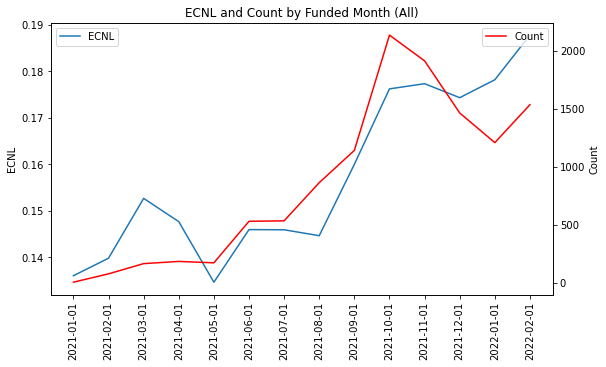

In [26]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('ECNL and Count by Funded Month (All)')
ax.set_ylabel('ECNL')
# ecnl
ax.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['ecnl'], label='ECNL')
ax.set_xticklabels(df_prod_grouped_tmp['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

In [27]:
# rm those with very few obs
int_threshold_obs = 500
df_prod_grouped_tmp = df_prod_grouped_tmp[df_prod_grouped_tmp['count'] >= int_threshold_obs]
df_prod_grouped_tmp

,dtmFunded_first,ecnl,count
5,2021-06-01,0.145988,532
6,2021-07-01,0.145950,536
7,2021-08-01,0.144678,865
8,2021-09-01,0.160019,1143
9,2021-10-01,0.176252,2137
10,2021-11-01,0.177364,1915
11,2021-12-01,0.174358,1466
12,2022-01-01,0.178208,1210
13,2022-02-01,0.187813,1537


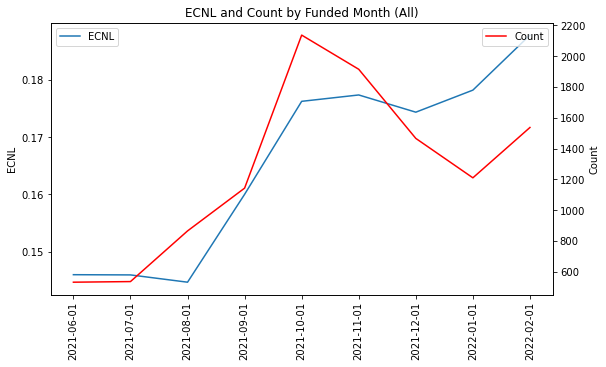

In [28]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('ECNL and Count by Funded Month (All)')
ax.set_ylabel('ECNL')
# ecnl
ax.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['ecnl'], label='ECNL')
ax.set_xticklabels(df_prod_grouped_tmp['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

### Get actual loss by funding month

In [29]:
df_target_grouped = df_target.groupby(by='dtmFunded_first', as_index=False).agg({
    'prop_loss': 'mean',
    'count': 'sum',
})
df_target_grouped

,dtmFunded_first,prop_loss,count
0,2017-08-01,0.055736,2104
1,2017-09-01,0.057653,1719
2,2017-10-01,0.064406,1728
3,2017-11-01,0.059274,1643
4,2017-12-01,0.064714,1478
5,2018-01-01,0.069636,1681
6,2018-02-01,0.057559,1266
7,2018-03-01,0.051478,1430
8,2018-04-01,0.069299,1498
9,2018-05-01,0.077874,2192


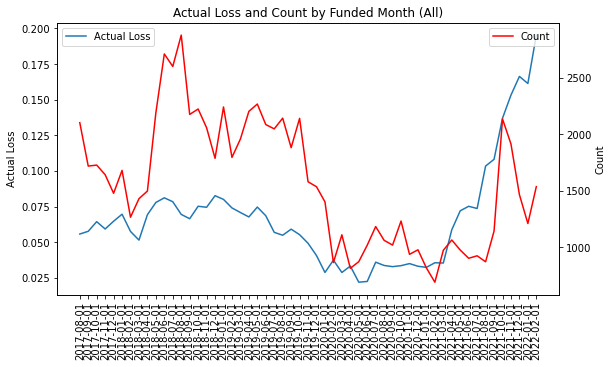

In [30]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual Loss and Count by Funded Month (All)')
ax.set_ylabel('Actual Loss')
# ecnl
ax.plot(df_target_grouped['dtmFunded_first'].astype(str), df_target_grouped['prop_loss'], label='Actual Loss')
ax.set_xticklabels(df_target_grouped['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_target_grouped['dtmFunded_first'].astype(str), df_target_grouped['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

### Join

In [31]:
df_joined = pd.merge(
    left=df_prod_grouped_tmp,
    right=df_target_grouped,
    on='dtmFunded_first',
    how='inner',
)
df_joined

,dtmFunded_first,ecnl,count_x,prop_loss,count_y
0,2021-06-01,0.145988,532,0.075200,902
1,2021-07-01,0.145950,536,0.073652,924
2,2021-08-01,0.144678,865,0.103444,871
3,2021-09-01,0.160019,1143,0.108152,1143
4,2021-10-01,0.176252,2137,0.136992,2137
5,2021-11-01,0.177364,1915,0.153206,1915
6,2021-12-01,0.174358,1466,0.166320,1466
7,2022-01-01,0.178208,1210,0.161364,1210
8,2022-02-01,0.187813,1537,0.195313,1537


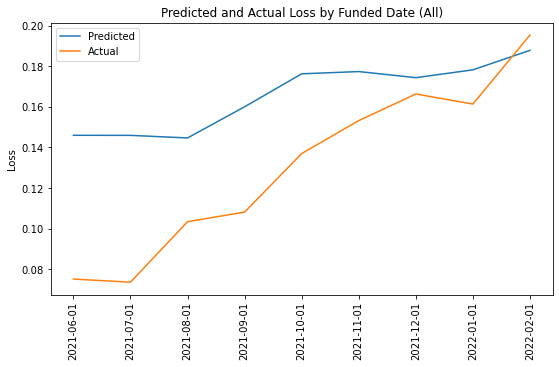

In [32]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Predicted and Actual Loss by Funded Date (All)')
ax.set_ylabel('Loss')
ax.plot(df_joined['dtmFunded_first'].astype(str), df_joined['ecnl'], label='Predicted')
ax.plot(df_joined['dtmFunded_first'].astype(str), df_joined['prop_loss'], label='Actual')
ax.set_xticklabels(df_joined['dtmFunded_first'].astype(str), rotation=90)
plt.legend()

# save
str_filename = 'plt_all.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

## BK

### Get predicted loss in production by funding month

In [33]:
df_tmp = df_prod_grouped[df_prod_grouped['intopenbktype__app'] != 'nan'].copy()
df_prod_grouped_tmp = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'ecnl': 'mean',
    'count': 'sum',
})
df_prod_grouped_tmp

,dtmFunded_first,ecnl,count
0,2021-01-01,0.041908,2
1,2021-02-01,0.099776,37
2,2021-03-01,0.121833,71
3,2021-04-01,0.115828,82
4,2021-05-01,0.080844,79
5,2021-06-01,0.106228,243
6,2021-07-01,0.103157,216
7,2021-08-01,0.105018,323
8,2021-09-01,0.099080,334
9,2021-10-01,0.112112,418


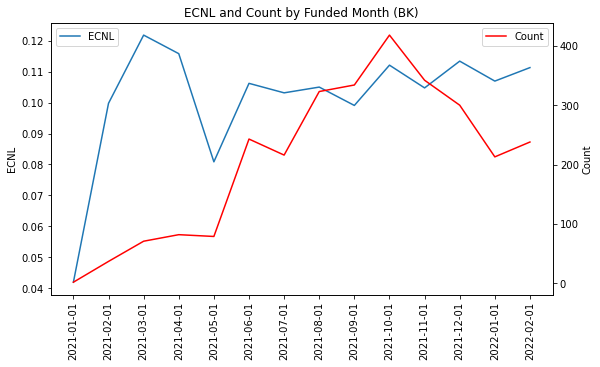

In [34]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('ECNL and Count by Funded Month (BK)')
ax.set_ylabel('ECNL')
# ecnl
ax.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['ecnl'], label='ECNL')
ax.set_xticklabels(df_prod_grouped_tmp['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

In [35]:
# rm those with very few obs
int_threshold_obs = 200
df_prod_grouped_tmp = df_prod_grouped_tmp[df_prod_grouped_tmp['count'] >= int_threshold_obs]
df_prod_grouped_tmp

,dtmFunded_first,ecnl,count
5,2021-06-01,0.106228,243
6,2021-07-01,0.103157,216
7,2021-08-01,0.105018,323
8,2021-09-01,0.099080,334
9,2021-10-01,0.112112,418
10,2021-11-01,0.104754,342
11,2021-12-01,0.113411,300
12,2022-01-01,0.106957,213
13,2022-02-01,0.111321,238


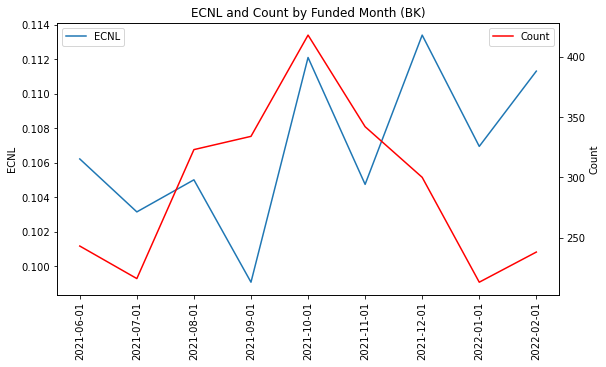

In [36]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('ECNL and Count by Funded Month (BK)')
ax.set_ylabel('ECNL')
# ecnl
ax.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['ecnl'], label='ECNL')
ax.set_xticklabels(df_prod_grouped_tmp['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

### Get actual loss by funding month

In [37]:
df_tmp = df_target[df_target['intOpenBKType'] != 'nan'].copy()
df_target_grouped = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'prop_loss': 'mean',
    'count': 'sum',
})
df_target_grouped

,dtmFunded_first,prop_loss,count
0,2017-08-01,0.053185,1050
1,2017-09-01,0.048434,898
2,2017-10-01,0.055702,938
3,2017-11-01,0.055754,900
4,2017-12-01,0.054633,773
5,2018-01-01,0.057968,820
6,2018-02-01,0.049866,642
7,2018-03-01,0.035856,712
8,2018-04-01,0.053810,714
9,2018-05-01,0.043545,809


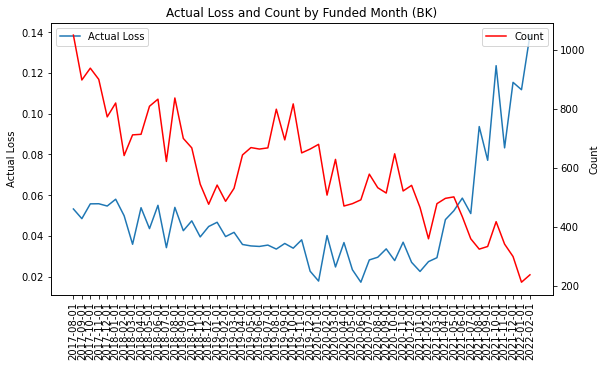

In [38]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual Loss and Count by Funded Month (BK)')
ax.set_ylabel('Actual Loss')
# ecnl
ax.plot(df_target_grouped['dtmFunded_first'].astype(str), df_target_grouped['prop_loss'], label='Actual Loss')
ax.set_xticklabels(df_target_grouped['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_target_grouped['dtmFunded_first'].astype(str), df_target_grouped['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

### Join

In [39]:
df_joined = pd.merge(
    left=df_prod_grouped_tmp,
    right=df_target_grouped,
    on='dtmFunded_first',
    how='inner',
)
df_joined

,dtmFunded_first,ecnl,count_x,prop_loss,count_y
0,2021-06-01,0.106228,243,0.058518,435
1,2021-07-01,0.103157,216,0.050938,360
2,2021-08-01,0.105018,323,0.093639,325
3,2021-09-01,0.099080,334,0.077081,334
4,2021-10-01,0.112112,418,0.123541,418
5,2021-11-01,0.104754,342,0.083194,342
6,2021-12-01,0.113411,300,0.115361,300
7,2022-01-01,0.106957,213,0.111739,213
8,2022-02-01,0.111321,238,0.138550,238


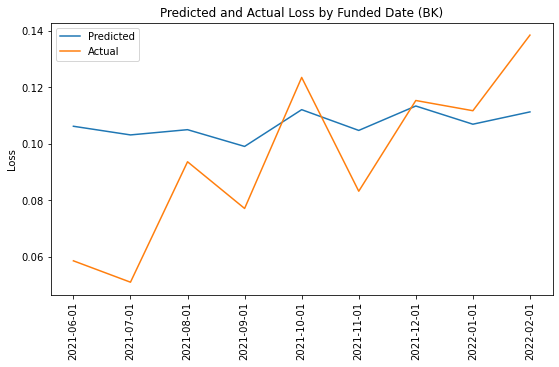

In [40]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Predicted and Actual Loss by Funded Date (BK)')
ax.set_ylabel('Loss')
ax.plot(df_joined['dtmFunded_first'].astype(str), df_joined['ecnl'], label='Predicted')
ax.plot(df_joined['dtmFunded_first'].astype(str), df_joined['prop_loss'], label='Actual')
ax.set_xticklabels(df_joined['dtmFunded_first'].astype(str), rotation=90)
plt.legend()

# save
str_filename = 'plt_bk.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

## No BK

### Get predicted loss in production by funding month

In [41]:
df_tmp = df_prod_grouped[df_prod_grouped['intopenbktype__app'] == 'nan'].copy()
df_prod_grouped_tmp = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'ecnl': 'mean',
    'count': 'sum',
})
df_prod_grouped_tmp

,dtmFunded_first,ecnl,count
0,2021-01-01,0.173739,5
1,2021-02-01,0.175126,42
2,2021-03-01,0.175533,96
3,2021-04-01,0.172828,104
4,2021-05-01,0.179445,95
5,2021-06-01,0.179418,289
6,2021-07-01,0.174835,320
7,2021-08-01,0.168313,542
8,2021-09-01,0.185178,809
9,2021-10-01,0.191849,1719


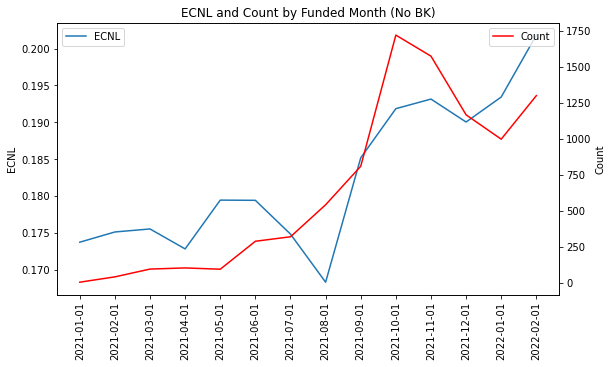

In [42]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('ECNL and Count by Funded Month (No BK)')
ax.set_ylabel('ECNL')
# ecnl
ax.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['ecnl'], label='ECNL')
ax.set_xticklabels(df_prod_grouped_tmp['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

In [43]:
# rm those with very few obs
int_threshold_obs = 200
df_prod_grouped_tmp = df_prod_grouped_tmp[df_prod_grouped_tmp['count'] >= int_threshold_obs]
df_prod_grouped_tmp

,dtmFunded_first,ecnl,count
5,2021-06-01,0.179418,289
6,2021-07-01,0.174835,320
7,2021-08-01,0.168313,542
8,2021-09-01,0.185178,809
9,2021-10-01,0.191849,1719
10,2021-11-01,0.193151,1573
11,2021-12-01,0.190039,1166
12,2022-01-01,0.193430,997
13,2022-02-01,0.201828,1299


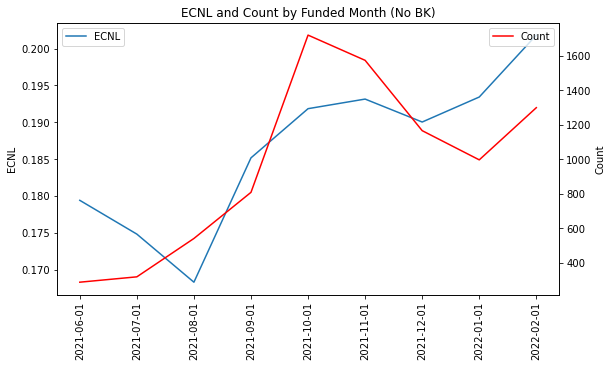

In [44]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('ECNL and Count by Funded Month (No BK)')
ax.set_ylabel('ECNL')
# ecnl
ax.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['ecnl'], label='ECNL')
ax.set_xticklabels(df_prod_grouped_tmp['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

### Get actual loss by funding month

In [45]:
df_tmp = df_target[df_target['intOpenBKType'] == 'nan'].copy()
df_target_grouped = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'prop_loss': 'mean',
    'count': 'sum',
})
df_target_grouped

,dtmFunded_first,prop_loss,count
0,2017-08-01,0.058276,1054
1,2017-09-01,0.067737,821
2,2017-10-01,0.074741,790
3,2017-11-01,0.063538,743
4,2017-12-01,0.075767,705
5,2018-01-01,0.080749,861
6,2018-02-01,0.065474,624
7,2018-03-01,0.066970,718
8,2018-04-01,0.083404,784
9,2018-05-01,0.097955,1383


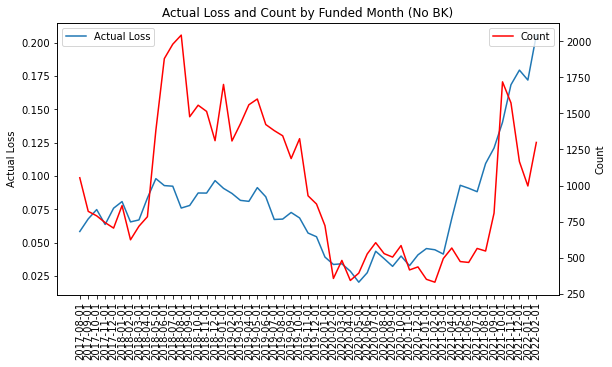

In [46]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual Loss and Count by Funded Month (No BK)')
ax.set_ylabel('Actual Loss')
# ecnl
ax.plot(df_target_grouped['dtmFunded_first'].astype(str), df_target_grouped['prop_loss'], label='Actual Loss')
ax.set_xticklabels(df_target_grouped['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_target_grouped['dtmFunded_first'].astype(str), df_target_grouped['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

### Join

In [47]:
df_joined = pd.merge(
    left=df_prod_grouped_tmp,
    right=df_target_grouped,
    on='dtmFunded_first',
    how='inner',
)
df_joined

,dtmFunded_first,ecnl,count_x,prop_loss,count_y
0,2021-06-01,0.179418,289,0.090739,467
1,2021-07-01,0.174835,320,0.088150,564
2,2021-08-01,0.168313,542,0.109281,546
3,2021-09-01,0.185178,809,0.120979,809
4,2021-10-01,0.191849,1719,0.140263,1719
5,2021-11-01,0.193151,1573,0.168428,1573
6,2021-12-01,0.190039,1166,0.179431,1166
7,2022-01-01,0.193430,997,0.171966,997
8,2022-02-01,0.201828,1299,0.205714,1299


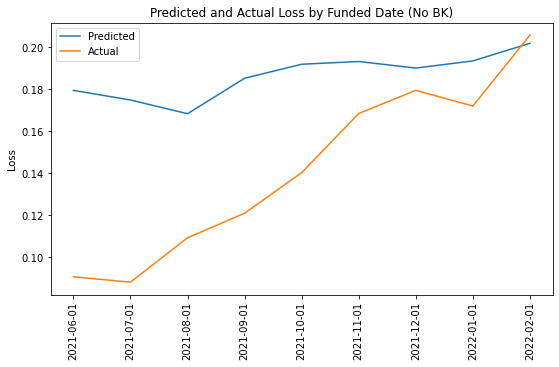

In [48]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Predicted and Actual Loss by Funded Date (No BK)')
ax.set_ylabel('Loss')
ax.plot(df_joined['dtmFunded_first'].astype(str), df_joined['ecnl'], label='Predicted')
ax.plot(df_joined['dtmFunded_first'].astype(str), df_joined['prop_loss'], label='Actual')
ax.set_xticklabels(df_joined['dtmFunded_first'].astype(str), rotation=90)
plt.legend()

# save
str_filename = 'plt_nobk.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

plt.show()

## BK7

### Get predicted loss in production by funding month


In [49]:
df_tmp = df_prod_grouped[df_prod_grouped['intopenbktype__app'] == '7.0'].copy()
df_prod_grouped_tmp = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'ecnl': 'mean',
    'count': 'sum',
})
df_prod_grouped_tmp

,dtmFunded_first,ecnl,count
0,2021-01-01,0.023259,1
1,2021-02-01,0.097136,26
2,2021-03-01,0.136534,43
3,2021-04-01,0.119583,52
4,2021-05-01,0.080014,47
5,2021-06-01,0.113475,177
6,2021-07-01,0.102060,125
7,2021-08-01,0.103634,198
8,2021-09-01,0.101918,227
9,2021-10-01,0.116180,293


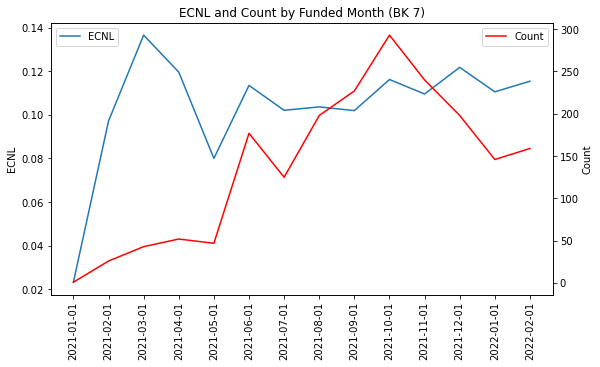

In [50]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('ECNL and Count by Funded Month (BK 7)')
ax.set_ylabel('ECNL')
# ecnl
ax.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['ecnl'], label='ECNL')
ax.set_xticklabels(df_prod_grouped_tmp['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

In [51]:
# rm those with very few obs
int_threshold_obs = 100
df_prod_grouped_tmp = df_prod_grouped_tmp[df_prod_grouped_tmp['count'] >= int_threshold_obs]
df_prod_grouped_tmp

,dtmFunded_first,ecnl,count
5,2021-06-01,0.113475,177
6,2021-07-01,0.102060,125
7,2021-08-01,0.103634,198
8,2021-09-01,0.101918,227
9,2021-10-01,0.116180,293
10,2021-11-01,0.109541,240
11,2021-12-01,0.121749,198
12,2022-01-01,0.110533,146
13,2022-02-01,0.115396,159


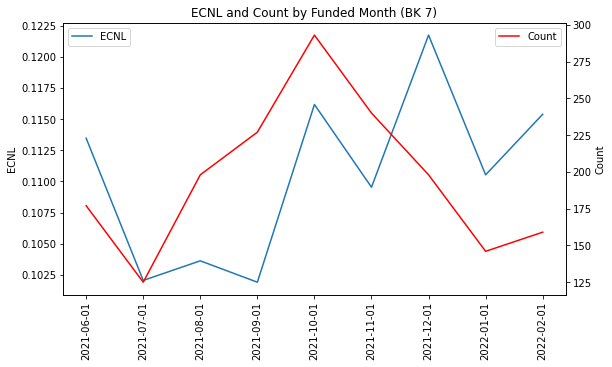

In [52]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('ECNL and Count by Funded Month (BK 7)')
ax.set_ylabel('ECNL')
# ecnl
ax.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['ecnl'], label='ECNL')
ax.set_xticklabels(df_prod_grouped_tmp['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_prod_grouped_tmp['dtmFunded_first'].astype(str), df_prod_grouped_tmp['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

### Get actual loss by funding month


In [53]:
df_tmp = df_target[df_target['intOpenBKType'] == '7.0'].copy()
df_target_grouped = df_tmp.groupby(by='dtmFunded_first', as_index=False).agg({
    'prop_loss': 'mean',
    'count': 'sum',
})
df_target_grouped

,dtmFunded_first,prop_loss,count
0,2017-08-01,0.058060,776
1,2017-09-01,0.051340,634
2,2017-10-01,0.063089,678
3,2017-11-01,0.053828,633
4,2017-12-01,0.058727,558
5,2018-01-01,0.061176,549
6,2018-02-01,0.060613,426
7,2018-03-01,0.039496,487
8,2018-04-01,0.062145,529
9,2018-05-01,0.048578,641


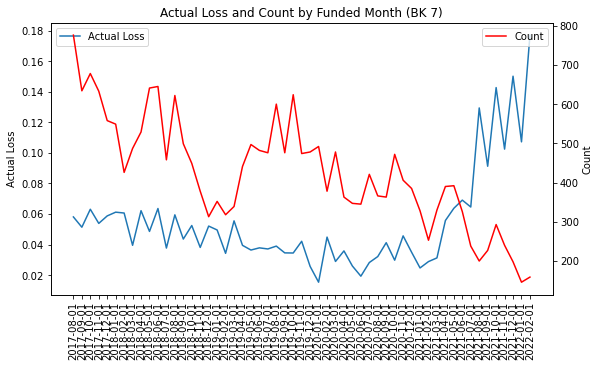

In [54]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual Loss and Count by Funded Month (BK 7)')
ax.set_ylabel('Actual Loss')
# ecnl
ax.plot(df_target_grouped['dtmFunded_first'].astype(str), df_target_grouped['prop_loss'], label='Actual Loss')
ax.set_xticklabels(df_target_grouped['dtmFunded_first'].astype(str), rotation=90)
plt.legend(loc='upper left')
# count
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(df_target_grouped['dtmFunded_first'].astype(str), df_target_grouped['count'], color='red', label='Count')
plt.legend(loc='upper right')
# show
plt.show()

### Join

In [55]:
df_joined = pd.merge(
    left=df_prod_grouped_tmp,
    right=df_target_grouped,
    on='dtmFunded_first',
    how='inner',
)
df_joined

,dtmFunded_first,ecnl,count_x,prop_loss,count_y
0,2021-06-01,0.113475,177,0.069047,326
1,2021-07-01,0.102060,125,0.064552,238
2,2021-08-01,0.103634,198,0.129354,200
3,2021-09-01,0.101918,227,0.091210,227
4,2021-10-01,0.116180,293,0.142666,293
5,2021-11-01,0.109541,240,0.102419,240
6,2021-12-01,0.121749,198,0.150105,198
7,2022-01-01,0.110533,146,0.107174,146
8,2022-02-01,0.115396,159,0.176993,159


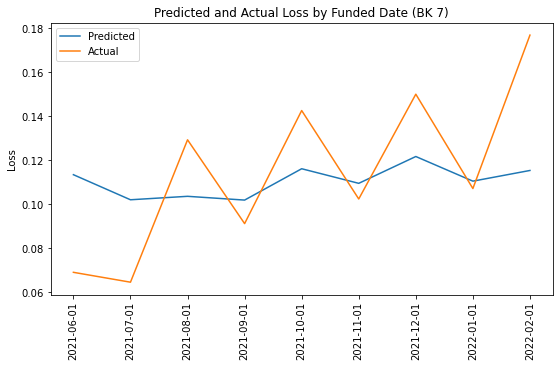

In [56]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Predicted and Actual Loss by Funded Date (BK 7)')
ax.set_ylabel('Loss')
ax.plot(df_joined['dtmFunded_first'].astype(str), df_joined['ecnl'], label='Predicted')
ax.plot(df_joined['dtmFunded_first'].astype(str), df_joined['prop_loss'], label='Actual')
ax.set_xticklabels(df_joined['dtmFunded_first'].astype(str), rotation=90)
plt.legend()

# save
str_filename = 'plt_bk7.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

### Clean-up

In [57]:
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in list_str_filename:
    os.remove(str_filename)